# Phase 2 — VORP Target Construction

This notebook builds the inputs needed to compute Value Over Replacement Player (VORP) for the keeper/trade engine. It starts by measuring real, empirical league behavior rather than assuming textbook defaults — the first section below measures the actual 2025 FLEX split, and later sections (as they're added) will reuse that split when computing replacement level per position.

## 1. Measuring the real 2025 FLEX split

Replacement level depends on how many effective roster spots exist per position — and this league's 3 FLEX slots can be filled by RB, WR, or TE, so a hidden assumption about *how* those FLEX starts actually split across positions silently biases every downstream VORP number.

Rather than assume an even split (or copy a number from another league), this section measures it directly from real 2025 lineup data:

- **Only 2025** is used: 2024 ran a 2-FLEX format (different roster construction, not comparable), and 2026's season isn't complete yet. 2025 is the one full season on record with the current 3-FLEX format.
- For every week, every roster's actual `starters` list is zipped positionally against the league's `roster_positions` (the ordered slot list, e.g. `[QB, RB, RB, WR, WR, TE, FLEX, FLEX, FLEX, K, DEF]`) to find which player occupied each FLEX slot.
- That player's real position (RB/WR/TE) is looked up in the Sleeper player dictionary to tally the actual split.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Allow imports from the repo root when running this notebook from notebooks/.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.ingestion import sleeper_client as sc
from src.keeper_ledger.build_ledger import load_keeper_rules
from scripts.sanity_check_2026_keepers import load_players

TARGET_SEASON = 2025
REGULAR_SEASON_WEEKS = range(1, 15)  # adjust if your league's regular season length differs

In [2]:
def find_season_league_id(current_league_id: str, target_season: int) -> str:
    """Walk the previous_league_id chain back to find the league_id that
    corresponds to a specific season."""
    for league in sc.get_league_chain(current_league_id):
        if int(league["season"]) == target_season:
            return league["league_id"]
    raise ValueError(f"Season {target_season} not found in this league's chain.")


rules = load_keeper_rules()
current_league_id = rules["league_id"]

season_league_id = find_season_league_id(current_league_id, TARGET_SEASON)
league = sc.get_league(season_league_id)
roster_positions = league["roster_positions"]  # ordered, includes BN/IR/TAXI too

print(f"2025 league_id: {season_league_id}")
print(f"roster_positions: {roster_positions}")

2025 league_id: 1250145989881241600
roster_positions: ['QB', 'RB', 'RB', 'WR', 'WR', 'TE', 'FLEX', 'FLEX', 'FLEX', 'K', 'DEF', 'BN', 'BN', 'BN', 'BN', 'BN', 'BN', 'BN']


In [3]:
players = load_players()
flex_position_counts = {"RB": 0, "WR": 0, "TE": 0, "OTHER": 0}
weeks_pulled = 0

for week in REGULAR_SEASON_WEEKS:
    try:
        matchups = sc.get_matchups(season_league_id, week)
    except Exception as e:
        print(f"Week {week}: fetch failed ({e}), skipping")
        continue
    if not matchups:
        continue
    weeks_pulled += 1

    for roster in matchups:
        starters = roster.get("starters") or []
        # starters is ordered to match roster_positions, EXCLUDING
        # bench/taxi/IR slots — so zip against only the starting
        # (non-BN/non-IR/non-taxi) slots, in order.
        starting_slots = [s for s in roster_positions if s not in ("BN", "IR", "TAXI")]

        for slot, player_id in zip(starting_slots, starters):
            if slot != "FLEX" or player_id is None:
                continue
            p = players.get(str(player_id), {})
            pos = p.get("position", "OTHER")
            if pos in flex_position_counts:
                flex_position_counts[pos] += 1
            else:
                flex_position_counts["OTHER"] += 1

total_flex_starts = sum(flex_position_counts.values())
print(f"Pulled {weeks_pulled} weeks. Total FLEX starts observed: {total_flex_starts}")
print(f"Raw counts: {flex_position_counts}")

Pulled 14 weeks. Total FLEX starts observed: 420
Raw counts: {'RB': 151, 'WR': 231, 'TE': 37, 'OTHER': 1}


In [4]:
if total_flex_starts == 0:
    raise RuntimeError("No FLEX starts found — check roster_positions/starters data before trusting this.")

# This is the variable later sections of this notebook reuse when
# computing replacement level per position — no separate JSON file
# needed, it all stays in one place.
flex_split_2025 = {
    pos: round(count / total_flex_starts, 4)
    for pos, count in flex_position_counts.items()
    if pos != "OTHER"
}

print(f"Measured 2025 FLEX split (RB/WR/TE only, OTHER excluded): {flex_split_2025}")

Measured 2025 FLEX split (RB/WR/TE only, OTHER excluded): {'RB': 0.3595, 'WR': 0.55, 'TE': 0.0881}


Visualizing it is basically free in a notebook, and it makes the assumption easy for a reviewer to sanity-check at a glance — does this match what you'd expect for a 3-FLEX league, or does something look off (e.g. suspiciously high TE share)?

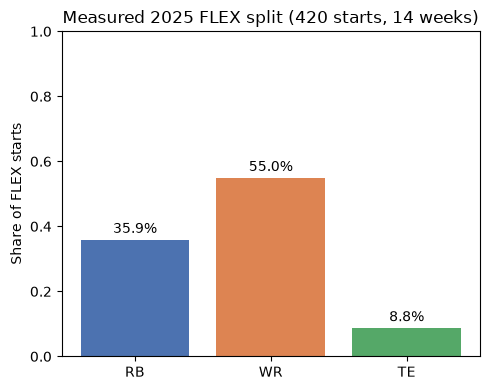

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
positions = list(flex_split_2025.keys())
shares = [flex_split_2025[p] for p in positions]

bars = ax.bar(positions, shares, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Share of FLEX starts")
ax.set_title(f"Measured {TARGET_SEASON} FLEX split ({total_flex_starts} starts, {weeks_pulled} weeks)")
ax.set_ylim(0, 1)

for bar, share in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{share:.1%}",
            ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 2. Replacement level per position per season

One methodological choice up front, since it affects every number below: the **FLEX percentage split** (RB/WR/TE shares of FLEX starts) is held constant at the 2025-measured value (`flex_split_2025` from Section 1) across every season, while the **FLEX slot count** is pulled fresh per season from that season's actual `roster_positions`.

That asymmetry is deliberate, not an oversight:
- The *slot count* (how many FLEX slots existed) is a known league setting recorded directly in Sleeper's historical data for every season — there's nothing to assume, it's just a fact we can read off per season (2024 ran 2 FLEX, 2025 ran 3).
- The *percentage split* (how those FLEX starts actually divide across RB/WR/TE) can only be measured by walking real week-by-week lineup data — which this notebook only did for 2025. Re-measuring it for earlier seasons would mean re-running Section 1's matchup pull against those seasons too; that's a reasonable future improvement, but out of scope here. Using the one real measurement we have is a more defensible stand-in than inventing a split with no empirical basis.

With that settled, demand per position per season is built as:

```
total_demand(season, position) = dedicated_starters(position) × teams
                                  + (flex_slots(season) × teams × flex_split_2025(position))
```

rounded to the nearest whole slot — where `dedicated_starters` and `teams` come from `config/roster_settings.yaml`, and QB/K/DEF get no FLEX share (they're never FLEX-eligible in this league).

Replacement level is then read directly off `scored_seasonal_stats.csv`: rank every player at that position for that season by `custom_fantasy_points`, and average the 4 players sitting just past the demand cutoff (e.g. demand 31 → average of ranks 32–35) — the next few bodies a team would actually be forced to start if every "starter-worthy" slot in the league were already filled.

### Why was this only ever using 2024–2025? And how far back can it actually go?

`scored_seasonal_stats.csv` itself has always had the full 2008–2025 range (10,873 fantasy-position rows) — it was never a stale file. The restriction came from the FLEX-slot cell below: `sc.get_league_chain(current_league_id)` only returns 3 seasons for this league, because **this specific Sleeper league's `previous_league_id` chain terminates at 2024** (2024's league record has `previous_league_id: None` — the league didn't exist on Sleeper before that). `demand_df` — and therefore `replacement_lookup` — was built only from those 3 seasons, and `vorp_df = scored.merge(replacement_lookup, on=["season","position"], how="inner")` silently dropped every other season via that inner join. Not a bug, not a stale file — just an inner merge quietly acting as a season filter with no line of code that looks like one.

That splits into two genuinely separate questions:

1. **Is `scored_seasonal_stats.csv` itself trustworthy that far back?** Checked below directly — null rates and suspicious-all-zero checks across every column the scoring formula actually touches (fumbles, FG buckets, PATs, 2pt conversions, games/attempts), across all 18 seasons.
2. **Do we know this league's real roster structure before 2024?** No — and no amount of data-quality checking on the stats file changes that. The Sleeper chain simply has no record of it. Extending the FLEX-slot count backward past 2024 is unavoidably an *assumption*, not a fact — a different kind of claim than the "known league setting" framing used for the real 2024–2026 values.

In [6]:
# Data-quality check: does any season have a suspiciously high null rate,
# or a suspicious all-zero column, in exactly the stats compute_fantasy_points()
# actually uses? (Not the whole 149-column dataset — just what matters here.)
import pandas as pd

raw = pd.read_csv(REPO_ROOT / "data/raw/raw_seasonal_stats.csv")
fantasy_all = raw[raw["position"].isin(["QB", "RB", "WR", "TE", "K"])]

SCORING_COLUMNS = [
    "fumbles_lost_total",
    "fg_made_0_19", "fg_made_20_29", "fg_made_30_39", "fg_made_40_49", "fg_made_50_59", "fg_made_60_",
    "fg_missed", "fg_blocked", "pat_made", "pat_missed", "pat_blocked",
    "passing_2pt_conversions", "rushing_2pt_conversions", "receiving_2pt_conversions",
    "games", "attempts",
]

print("Null rate by season (only flagging > 5%):")
any_flagged = False
for col in SCORING_COLUMNS:
    null_by_season = fantasy_all.groupby("season")[col].apply(lambda s: s.isna().mean())
    flagged = null_by_season[null_by_season > 0.05]
    if len(flagged):
        any_flagged = True
        print(f"  {col}: {dict(flagged.round(2))}")
if not any_flagged:
    print("  none — every scoring-relevant column is populated across all 18 seasons (2008-2025).")

print()
print("Season-mean sanity check for the kicking distance buckets (checking for a season where a")
print("column is suspiciously always 0, which would suggest that stat wasn't tracked yet):")
k = raw[raw["position"] == "K"]
print(k.groupby("season")[["fg_made_0_19", "fg_made_50_59", "fg_made_60_", "fg_blocked", "pat_blocked"]].mean().round(2).to_string())

print()
print("Real rule-change context visible in the data (not data-quality problems — genuine NFL")
print("rule changes, already handled correctly since replacement level is computed within-season):")
print("  - PAT distance moved back in 2015 -> pat_missed rate jumps from ~0.1 to ~1.0+ per kicker that year.")
print("  - Season length went 16 -> 17 games starting 2021 -> raises the ceiling on counting stats.")

Null rate by season (only flagging > 5%):
  none — every scoring-relevant column is populated across all 18 seasons (2008-2025).

Season-mean sanity check for the kicking distance buckets (checking for a season where a
column is suspiciously always 0, which would suggest that stat wasn't tracked yet):
        fg_made_0_19  fg_made_50_59  fg_made_60_  fg_blocked  pat_blocked
season                                                                   
2008            0.18           1.65         0.00        0.55         0.08
2009            0.26           1.29         0.02        0.50         0.33
2010            0.44           1.35         0.02        0.42         0.07
2011            0.43           2.41         0.03        0.81         0.14
2012            0.42           2.34         0.08        0.55         0.11
2013            0.35           2.76         0.06        0.47         0.12
2014            0.26           2.47         0.00        0.82         0.16
2015            0.25           

**Decision: use the full 2008–2025 range.** No column the scoring formula depends on has a meaningful gap in any season — the two visible shifts in the data (the 2015 PAT-distance rule change, the 2021 16→17 game season) are real NFL rule changes, not tracking gaps, and neither corrupts anything here since replacement level is always computed from that season's own real player pool, not compared raw across eras.

For the roster-structure assumption this unavoidably requires: seasons **2024–2026 keep their real, Sleeper-recorded FLEX-slot counts** (2, 3, 3). Every season from **2008–2023** assumes the **current 3-FLEX format** (the format still in effect today, per `config/roster_settings.yaml`) rather than inventing a different guess — flagged plainly as an assumption, not a known fact, everywhere it's used from here on.

In [7]:
import math

import pandas as pd
import yaml

EARLIEST_USABLE_SEASON = 2008  # scored_seasonal_stats.csv's full range; see data-quality check above
CURRENT_FLEX_SLOTS = 3  # the format still in effect today (2025/2026) — the assumed default pre-2024

# REAL, Sleeper-recorded FLEX slot counts — only exists for this league's
# actual history (2024 onward; the chain has no record before that).
known_flex_slots_by_season = {}
for league_season in sc.get_league_chain(current_league_id):
    s = int(league_season["season"])
    known_flex_slots_by_season[s] = league_season["roster_positions"].count("FLEX")

latest_known_season = max(known_flex_slots_by_season)

# Extend backward: real value where we have one, ASSUMED current-format
# value everywhere else. is_assumed tracks which is which so it's never
# silently ambiguous later.
flex_slots_by_season = {}
flex_slots_is_assumed = {}
for season in range(EARLIEST_USABLE_SEASON, latest_known_season + 1):
    if season in known_flex_slots_by_season:
        flex_slots_by_season[season] = known_flex_slots_by_season[season]
        flex_slots_is_assumed[season] = False
    else:
        flex_slots_by_season[season] = CURRENT_FLEX_SLOTS
        flex_slots_is_assumed[season] = True

print("FLEX slots by season (asterisk = assumed, not a real Sleeper record):")
for season in sorted(flex_slots_by_season):
    marker = "*" if flex_slots_is_assumed[season] else ""
    print(f"  {season}: {flex_slots_by_season[season]}{marker}")

with open("config/roster_settings.yaml") as f:
    roster_settings = yaml.safe_load(f)

TOTAL_TEAMS = roster_settings["total_teams"]
# Dedicated (non-FLEX) starter counts per position — a known league
# setting, not something to infer.
DEDICATED_STARTERS = {pos: count for pos, count in roster_settings["starters"].items() if pos != "FLEX"}

print(f"\nTotal teams: {TOTAL_TEAMS}")
print(f"Dedicated starters: {DEDICATED_STARTERS}")

FLEX slots by season (asterisk = assumed, not a real Sleeper record):
  2008: 3*
  2009: 3*
  2010: 3*
  2011: 3*
  2012: 3*
  2013: 3*
  2014: 3*
  2015: 3*
  2016: 3*
  2017: 3*
  2018: 3*
  2019: 3*
  2020: 3*
  2021: 3*
  2022: 3*
  2023: 3*
  2024: 2
  2025: 3
  2026: 3

Total teams: 10
Dedicated starters: {'QB': 1, 'RB': 2, 'WR': 2, 'TE': 1, 'K': 1, 'DEF': 1}


In [8]:
def round_half_up(x: float) -> int:
    return math.floor(x + 0.5)


demand_rows = []
for season, flex_slots in sorted(flex_slots_by_season.items()):
    for position, dedicated_count in DEDICATED_STARTERS.items():
        dedicated_demand = dedicated_count * TOTAL_TEAMS
        # QB/K/DEF aren't FLEX-eligible in this league, so they get 0 share
        # via .get() — only RB/WR/TE (flex_split_2025's keys) get a cut.
        flex_share = flex_slots * TOTAL_TEAMS * flex_split_2025.get(position, 0)
        total_demand = round_half_up(dedicated_demand + flex_share)
        demand_rows.append({
            "season": season,
            "position": position,
            "dedicated_demand": dedicated_demand,
            "flex_share": round(flex_share, 2),
            "total_demand": total_demand,
        })

demand_df = pd.DataFrame(demand_rows)
print(demand_df.to_string(index=False))

 season position  dedicated_demand  flex_share  total_demand
   2008       QB                10        0.00            10
   2008       RB                20       10.79            31
   2008       WR                20       16.50            37
   2008       TE                10        2.64            13
   2008        K                10        0.00            10
   2008      DEF                10        0.00            10
   2009       QB                10        0.00            10
   2009       RB                20       10.79            31
   2009       WR                20       16.50            37
   2009       TE                10        2.64            13
   2009        K                10        0.00            10
   2009      DEF                10        0.00            10
   2010       QB                10        0.00            10
   2010       RB                20       10.79            31
   2010       WR                20       16.50            37
   2010       TE        

In [9]:
scored = pd.read_csv(REPO_ROOT / "data/processed/scored_seasonal_stats.csv")


def replacement_level(season: int, position: str, demand: int):
    """Average custom_fantasy_points of the 4 players ranked just past
    the demand cutoff (e.g. demand=31 -> average of ranks 32-35). None if
    there isn't enough data at that season/position to fill the window
    (no scored rows yet, or fewer than demand+4 players on record)."""
    pool = scored[(scored["season"] == season) & (scored["position"] == position)]
    pool = pool.sort_values("custom_fantasy_points", ascending=False)
    window = pool.iloc[demand:demand + 4]  # 0-indexed: ranks (demand+1)..(demand+4)
    if window.empty:
        return None
    return round(window["custom_fantasy_points"].mean(), 2)


demand_df["replacement_level"] = demand_df.apply(
    lambda r: replacement_level(r["season"], r["position"], r["total_demand"]), axis=1
)

result = demand_df[["season", "position", "total_demand", "replacement_level"]]
pd.set_option("display.max_rows", None)
print(result.to_string(index=False))

 season position  total_demand  replacement_level
   2008       QB            10             216.21
   2008       RB            31             135.86
   2008       WR            37             122.12
   2008       TE            13              91.05
   2008        K            10             128.25
   2008      DEF            10                NaN
   2009       QB            10             239.20
   2009       RB            31             139.12
   2009       WR            37             121.30
   2009       TE            13             111.02
   2009        K            10             113.50
   2009      DEF            10                NaN
   2010       QB            10             239.14
   2010       RB            31             119.90
   2010       WR            37             130.28
   2010       TE            13             106.28
   2010        K            10             117.38
   2010      DEF            10                NaN
   2011       QB            10             237.49


## 3. VORP per player-season

`VORP = custom_fantasy_points - replacement_level`, joined on `(season, position)` — every player gets compared against the replacement level for *their own* position in *their own* season, not a league-wide baseline.

**DEF is skipped entirely.** Section 2 left `replacement_level` as `NaN` for every DEF row — `scored_seasonal_stats.csv` has no team-defense stats at all (it's individual-player seasonal stats; team DEF is a different data shape Sleeper tracks separately), so there's no real baseline to subtract against yet. Computing `points - NaN` would just produce `NaN` VORP for every defense, which is worse than useless — it would silently pass through downstream and look like "no data" rather than what it actually is: "not modeled yet." Dropping those rows is more honest than keeping a column full of garbage.

2026 drops out naturally too, with no special-case needed for it: `scored_seasonal_stats.csv` only has stats through the 2025 season, so joining against it simply produces zero 2026 rows — there's no real performance to rank yet, so there's nothing to compute VORP against.

In [10]:
# Only positions with a real, computed replacement level — drop DEF
# (never modeled) and any season/position with no replacement_level yet.
replacement_lookup = (
    demand_df[demand_df["position"] != "DEF"][["season", "position", "replacement_level"]]
    .dropna(subset=["replacement_level"])
)

vorp_df = scored.merge(replacement_lookup, on=["season", "position"], how="inner")
vorp_df["vorp"] = vorp_df["custom_fantasy_points"] - vorp_df["replacement_level"]

print(f"{len(vorp_df)} player-season rows with VORP computed, "
      f"seasons: {sorted(vorp_df['season'].unique())}, "
      f"positions: {sorted(vorp_df['position'].unique())}")

10873 player-season rows with VORP computed, seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)], positions: ['K', 'QB', 'RB', 'TE', 'WR']


C:\Users\viraj\AppData\Local\Temp\ipykernel_11296\4073554026.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vorp_df["vorp"] = vorp_df["custom_fantasy_points"] - vorp_df["replacement_level"]


In [11]:
# Sanity check: top 5 by VORP per (season, position) — does this look
# like who was actually good that year?
top5_by_season_position = (
    vorp_df.sort_values("vorp", ascending=False)
    .groupby(["season", "position"])
    .head(5)
    .sort_values(["season", "position", "vorp"], ascending=[True, True, False])
)

pd.set_option("display.max_rows", None)
print(top5_by_season_position[
    ["season", "position", "player_display_name", "custom_fantasy_points", "replacement_level", "vorp"]
].to_string(index=False))

 season position  player_display_name  custom_fantasy_points  replacement_level   vorp
   2008        K   Stephen Gostkowski                 155.00             128.25  26.75
   2008        K          David Akers                 148.00             128.25  19.75
   2008        K          John Carney                 147.00             128.25  18.75
   2008        K          Rob Bironas                 140.00             128.25  11.75
   2008        K        Ryan Longwell                 140.00             128.25  11.75
   2008       QB           Drew Brees                 319.66             216.21 103.45
   2008       QB        Aaron Rodgers                 303.22             216.21  87.01
   2008       QB           Jay Cutler                 295.00             216.21  78.79
   2008       QB        Philip Rivers                 289.56             216.21  73.35
   2008       QB          Kurt Warner                 275.08             216.21  58.87
   2008       RB    DeAngelo Williams      

## 4. Building the target: VORP_next

The eventual model predicts *next* season's value from *this* season's (pre-season-available) information — so the label it needs to learn is each player's VORP one season forward, attached to the row for the season being predicted *from*.

Two things to get right here:

- **Join key is `player_id`, not `player_display_name`.** Section 3's underlying data has real name collisions across different people (two different NFL players named "Adrian Peterson" show up in the raw 2008/2009 rows) — shifting by name would silently splice unrelated players' careers together. `player_id` (nflreadpy's stable GSIS-style id) doesn't have that problem.
- **2025 rows keep `VORP_next = NaN` rather than getting dropped.** There's no 2026 scored data yet to shift in, so there's nothing to fill — but a 2025 row is exactly the shape of input a real prediction run needs (this season's info, predicting next season), so it stays in the table rather than disappearing.

Separately, **`is_rookie_cohort`** flags any player-season that is that player's *first* appearance anywhere in the full scored dataset (all seasons, all positions — not just the 2024/2025 window Section 3 computed VORP for). These rows have no `t-1` season to build lag-based features from later (age curve, prior-year usage trend, etc.), so Phase 3 feature engineering needs to know not to silently treat them like a normal veteran season with missing data. One honest caveat: the underlying seasonal stats only go back to 2008, so this really means "first appearance *in this dataset*" — a hypothetical player whose true rookie year predates 2008 would be mislabeled, but nobody in that category is still active today, so it's a non-issue in practice.

In [12]:
# Shift VORP forward one season per player_id: take each row's (player_id,
# season, vorp), relabel it as belonging to season-1, and left-join back
# onto vorp_df on (player_id, season) — so a 2025 row's vorp lands on the
# matching player's 2024 row as "vorp_next".
next_season_vorp = vorp_df[["player_id", "season", "vorp"]].copy()
next_season_vorp["season"] = next_season_vorp["season"] - 1
next_season_vorp = next_season_vorp.rename(columns={"vorp": "vorp_next"})

vorp_df = vorp_df.merge(next_season_vorp, on=["player_id", "season"], how="left")

n_with_label = vorp_df["vorp_next"].notna().sum()
n_without_label = vorp_df["vorp_next"].isna().sum()
print(f"VORP_next populated (usable for training): {n_with_label}")
print(f"VORP_next is NaN (no following season yet — e.g. 2025 rows): {n_without_label}")

VORP_next populated (usable for training): 7648
VORP_next is NaN (no following season yet — e.g. 2025 rows): 3225


In [13]:
# A player's rookie/first-appearance season is checked against the FULL
# scored dataset (all seasons back to 2008, all positions) — not just the
# 2024/2025 window vorp_df is restricted to — since a veteran's own
# earlier seasons live outside that window and must not be mistaken for
# "no history."
first_season_on_record = scored.groupby("player_id")["season"].min()
vorp_df["first_season_on_record"] = vorp_df["player_id"].map(first_season_on_record)
vorp_df["is_rookie_cohort"] = vorp_df["season"] == vorp_df["first_season_on_record"]
vorp_df = vorp_df.drop(columns=["first_season_on_record"])

n_rookie_cohort = vorp_df["is_rookie_cohort"].sum()
print(f"is_rookie_cohort rows: {n_rookie_cohort} out of {len(vorp_df)}")
print()
print("Summary:")
print(f"  VORP_next populated (usable for training): {n_with_label}")
print(f"  VORP_next is NaN (no following season yet):  {n_without_label}")
print(f"  is_rookie_cohort:                             {n_rookie_cohort}")

is_rookie_cohort rows: 2789 out of 10873

Summary:
  VORP_next populated (usable for training): 7648
  VORP_next is NaN (no following season yet):  3225
  is_rookie_cohort:                             2789


C:\Users\viraj\AppData\Local\Temp\ipykernel_11296\2138105044.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vorp_df["first_season_on_record"] = vorp_df["player_id"].map(first_season_on_record)
C:\Users\viraj\AppData\Local\Temp\ipykernel_11296\2138105044.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vorp_df["is_rookie_cohort"] = vorp_df["season"] == vorp_df["first_season_on_record"]


## 5. Distribution check

Before picking a loss function for the eventual model, look at what `VORP_next` actually looks like per position — a handful of elite breakout seasons can pull a right tail out of an otherwise ordinary distribution, and guessing at the shape instead of plotting it is exactly how a mismatched loss function sneaks in.

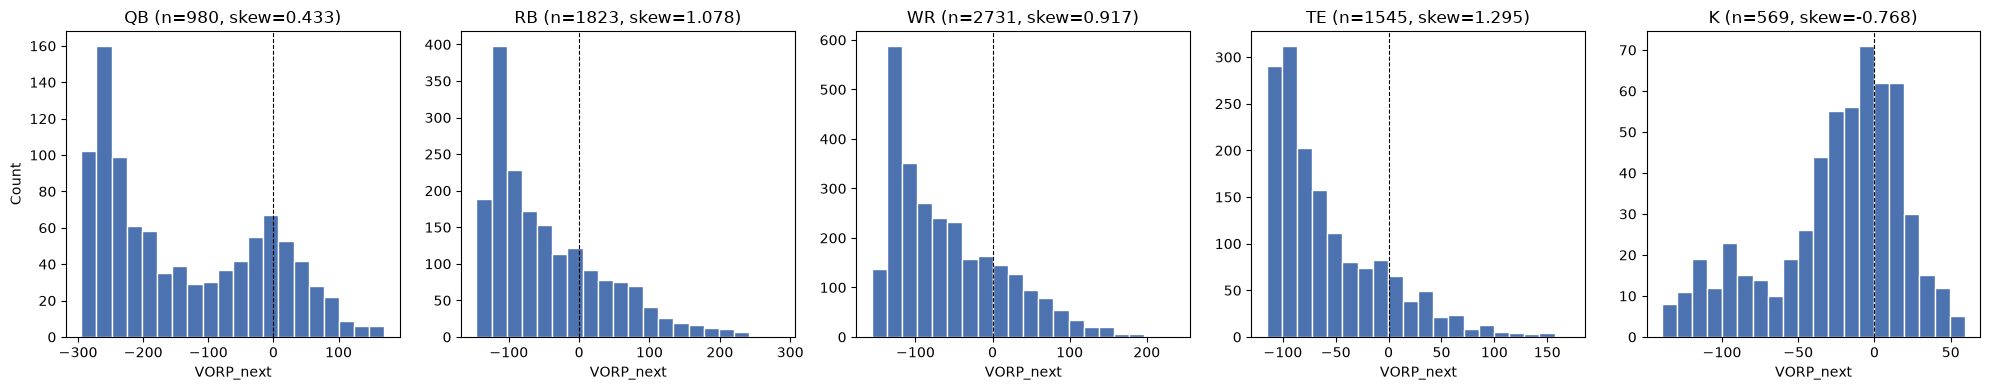

Skewness by position:
  QB: 0.433
  RB: 1.078
  WR: 0.917
  TE: 1.295
  K: -0.768

Value ranges (relevant for the transform choice below — note the negative floor):
  QB: min=-295.0  max=170.5  share_negative=0.8
  RB: min=-145.9  max=284.9  share_negative=0.74
  WR: min=-157.0  max=236.2  share_negative=0.78
  TE: min=-115.3  max=171.3  share_negative=0.85
  K: min=-139.5  max=59.2  share_negative=0.67


In [14]:
POSITIONS_ORDER = ["QB", "RB", "WR", "TE", "K"]
valid = vorp_df.dropna(subset=["vorp_next"])

fig, axes = plt.subplots(1, len(POSITIONS_ORDER), figsize=(20, 4), sharey=False)

skewness_by_position = {}
for ax, pos in zip(axes, POSITIONS_ORDER):
    series = valid[valid["position"] == pos]["vorp_next"]
    skewness_by_position[pos] = round(series.skew(), 3)
    ax.hist(series, bins=20, color="#4C72B0", edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{pos} (n={len(series)}, skew={skewness_by_position[pos]})")
    ax.set_xlabel("VORP_next")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Skewness by position:")
for pos, skew in skewness_by_position.items():
    print(f"  {pos}: {skew}")

print()
print("Value ranges (relevant for the transform choice below — note the negative floor):")
for pos in POSITIONS_ORDER:
    series = valid[valid["position"] == pos]["vorp_next"]
    print(f"  {pos}: min={series.min():.1f}  max={series.max():.1f}  share_negative={round((series < 0).mean(), 2)}")

In [15]:
# Diagnostic: is the QB left cluster (vorp_next < -150) dominated by
# backups with a tiny sample, or genuinely bad full/partial-season
# starters? IMPORTANT: vorp_next is the OUTCOME of the *following*
# season, so "games played" has to come from that same following season
# too — pulling the current row's own `games` would describe the wrong
# season entirely and tell us nothing about the season that actually
# produced the bad vorp_next value.
next_season_context = vorp_df[["player_id", "season", "games", "attempts"]].rename(
    columns={"season": "orig_season", "games": "games_next", "attempts": "attempts_next"}
)
next_season_context["season"] = next_season_context["orig_season"] - 1
next_season_context = next_season_context.drop(columns=["orig_season"])

qb_valid = valid[valid["position"] == "QB"].merge(next_season_context, on=["player_id", "season"], how="left")

low_cluster = qb_valid[qb_valid["vorp_next"] < -150].sort_values("vorp_next")
# QB VORP has much wider spread than the other positions, so the |x|<=15
# band used loosely elsewhere would only catch ~1 player here — widened
# to |x|<=30 to get an actual comparison group of real starters.
near_zero_cluster = qb_valid[qb_valid["vorp_next"].abs() <= 30].sort_values("vorp_next")

cols_to_show = ["player_display_name", "season", "games_next", "attempts_next", "vorp_next"]

print(f"QB left cluster, vorp_next < -150 (n={len(low_cluster)}):")
print(low_cluster[cols_to_show].to_string(index=False))

print()
print(f"QB near-zero cluster, |vorp_next| <= 30 (n={len(near_zero_cluster)}):")
print(near_zero_cluster[cols_to_show].to_string(index=False))

print()
print("games_next summary:")
print(f"  left cluster:      mean={low_cluster['games_next'].mean():.1f}  median={low_cluster['games_next'].median():.1f}")
print(f"  near-zero cluster: mean={near_zero_cluster['games_next'].mean():.1f}  median={near_zero_cluster['games_next'].median():.1f}")

print()
print("Left cluster games_next distribution:")
print(low_cluster["games_next"].value_counts().sort_index().to_string())

QB left cluster, vorp_next < -150 (n=524):
     player_display_name  season  games_next  attempts_next  vorp_next
              Geno Smith    2017           4              4    -294.96
         Jacoby Brissett    2017           4              4    -294.10
             Brian Hoyer    2017           5              2    -294.00
               Tim Boyle    2019           8              0    -293.64
            Sean Mannion    2017           3              3    -293.46
             AJ McCarron    2017           2              3    -293.36
         Jimmy Garoppolo    2014           4              4    -293.24
             Matt Schaub    2019           1              0    -293.14
                Joe Webb    2014           9              0    -293.08
            Chase Daniel    2014           2              2    -293.02
              Shaun Hill    2014           3              7    -292.88
              Matt Moore    2014           1              1    -292.62
        Tarvaris Jackson    2014  

### Finding: the QB left cluster is a real, persistent pattern — confirmed at 15x the original sample size

*(Updated on the full 2008–2025 range: left cluster n=524, near-zero cluster n=154 — up from n=34 and n=1/n=4 on the original small sample. Total QB rows: 980, vs. 63 before.)*

The earlier finding holds, and holds more clearly now that there's far more data to check it against. `games_next` for the two groups:

|  | n | mean games_next | median games_next |
|---|---|---|---|
| Left cluster (`vorp_next < -150`) | 524 | 4.2 | 4.0 |
| Near-zero cluster (`\|vorp_next\| <= 30`) | 154 | 15.6 | 16.0 |

That's not a fluke of a small sample — the left cluster's `games_next` distribution is heavily front-loaded: **319 of 524 (61%) played ≤4 games**, another **106 (20%)** played 5–6, and only **99 (19%)** played 7 or more. The near-zero cluster is almost entirely full-season starters (13–17 games). The histogram in the distribution-check cell above makes this visible directly: QB is the only position with two separate peaks and a real valley between them, not a single skewed hump like RB/WR/TE/K — this is a genuine structural bimodality in the position, not sampling noise from the earlier n=63.

The larger sample also surfaces real examples of the "genuine bad-but-substantial season" tail the small sample only hinted at (Jayden Daniels, Rattler, Cousins before) — now there's a much bigger set of them: Justin Fields (2023, 10 games, -165), Cooper Rush (2023, 12 games, -171), Kenny Pickett (2022, 12 games, -161), Mac Jones (2022, 11 games, -157), Will Levis (2023, 12 games, -154), Andrew Luck (2014, 7 games, -150) among others — real starters or extended-look backups who had genuinely poor seasons, not small-sample noise, sitting right at the edge of the -150 cutoff.

**Suggested threshold, still not applied:** `games_next >= 6` continues to look like the right rough cutoff — it removes the clear small-sample block (the ≤4-game group, 61% of the left cluster) while keeping the real partial/full-season busts intact. This is now backed by 15x the data that first suggested it, not a guess extrapolated from a handful of examples.

### Loss function recommendation: `reg:squarederror`

*(Updated on the full 2008–2025 range, n=7,648 — up from n=486 on the original 2024/2025-only data.)*

Skew, on the full range: **QB 0.43, RB 1.08, WR 0.92, TE 1.30, K -0.77.** The right-tail pull is still real for RB/WR/TE (moderate-to-strong, 0.9–1.3), still milder for QB, and K is still left-skewed, not right — the same qualitative pattern as the smaller sample, just with more stable numbers now that n is 15–20x larger per position.

But the histograms surface something skew alone doesn't capture: **QB is genuinely bimodal** — two separate peaks (one around -270, one around -20) with a real valley between them — while RB/WR/TE/K all show a single peak with a smooth, monotonically-decreasing tail. That's not a small-sample artifact (see the diagnostic above, now run at n=980 for QB, 15x the original n=63); it's a structural fact about the position: a QB season is much closer to binary — you're either the guy for most of the year or you're clearly not — whereas RB/WR/TE playing time is more of a continuum (committee backfields, rotational slot roles). A single regression loss can't fix that; it's a shape problem, not a skew problem, and worth carrying into Phase 3 as a candidate feature (e.g. a projected-starter flag) or a position-specific modeling choice, separate from whatever loss function gets picked here.

The same fact that ruled out `reg:tweedie` and plain `log1p` before still does, more firmly now that the sample is far larger: `VORP_next` goes negative for 67–85% of rows across every position (not an edge case — the majority case). `reg:tweedie` requires `y >= 0` outright; `log1p` is undefined for `x <= -1`, which most positions blow past by a wide margin. Both would need an arbitrary shift constant to even become usable, undoing any principled connection between the transform and the data's actual shape.

**`reg:squarederror`** remains the recommendation: it's the one option that handles the negative floor natively, and the skew (0.4–1.3, not 3+ territory) doesn't push hard enough against it to justify the cost of an arbitrary shift. If skew turns out to matter empirically once a model is trained, a **signed-log transform** (`sign(x) * log1p(abs(x))`) is still the right next thing to try — it stays defined for negative inputs unlike plain `log1p`. That's separate from the QB bimodality issue, which a loss-function change won't fix regardless.

### Flagging the QB low-snap cases: `low_snap_next_season`

The diagnostic above found the QB left cluster is a mix of two very different things sitting in the same games-played band: mostly small-sample noise (a backup's `VORP_next` built on 1–4 garbage-time snaps is close to meaningless as a label — the points total mostly reflects how few plays he got, not how good or bad he actually was), but also a real minority of genuine partial-season busts (Cousins, Rattler, Daniels, Justin Fields, and others) that happen to fall in the same low-game-count band.

That mix is exactly why this gets **flagged, not dropped** — following the same pattern as `is_rookie_cohort`. Hard-deleting every `games_next < 6` row would silently throw out the real bust cases along with the noise, and that's a modeling decision (exclude vs. downweight vs. keep) that belongs in Phase 4, once there's an actual model to evaluate the tradeoff against — not something to bake permanently into the saved label file now. Flagging keeps the decision reversible: Phase 4 can filter on this column, downweight by it, or ignore it entirely, and still recover the original unfiltered data underneath.

`low_snap_next_season` is `True` only for QB rows with `games_next < 6` — it's specific to QB (the position with the demonstrated bimodal split), not a general-purpose small-sample flag for every position.

In [16]:
LOW_SNAP_GAMES_THRESHOLD = 6

# Same shift-forward pattern used for vorp_next: pull games from the
# FOLLOWING season (not this row's own games) onto each row, as an
# intermediate column, then derive the flag and drop the intermediate —
# same treatment as first_season_on_record in the is_rookie_cohort step.
next_season_games = vorp_df[["player_id", "season", "games"]].rename(
    columns={"season": "orig_season", "games": "games_next"}
)
next_season_games["season"] = next_season_games["orig_season"] - 1
next_season_games = next_season_games.drop(columns=["orig_season"])

vorp_df = vorp_df.merge(next_season_games, on=["player_id", "season"], how="left")

# QB-specific: True only where position is QB AND games_next < threshold.
# NaN games_next (no following season on record) compares as False, so
# those rows correctly stay unflagged rather than raising or silently
# becoming True.
vorp_df["low_snap_next_season"] = (
    (vorp_df["position"] == "QB") & (vorp_df["games_next"] < LOW_SNAP_GAMES_THRESHOLD)
)
vorp_df = vorp_df.drop(columns=["games_next"])

n_flagged = vorp_df["low_snap_next_season"].sum()
n_qb = (vorp_df["position"] == "QB").sum()
print(f"low_snap_next_season flagged: {n_flagged} rows ({n_flagged}/{n_qb} = {n_flagged / n_qb:.1%} of QB rows)")

low_snap_next_season flagged: 379 rows (379/1366 = 27.7% of QB rows)


C:\Users\viraj\AppData\Local\Temp\ipykernel_11296\685779256.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vorp_df["low_snap_next_season"] = (


## 6. Save labels

Writing `vorp_df` out closes Phase 2's exit criterion from the roadmap: a labeled dataset — `VORP_next` as the training target (`NaN` for rows with no following season yet), `is_rookie_cohort` flagging first-appearance seasons, `low_snap_next_season` flagging QB rows whose label was built on a near-meaningless low-snap following season, and every column Section 3 built along the way — ready for Phase 3 feature engineering to join against.

In [17]:
output_path = REPO_ROOT / "data/processed/vorp_labels.parquet"
vorp_df.to_parquet(output_path, index=False)
print(f"Saved {len(vorp_df)} rows ({vorp_df['vorp_next'].notna().sum()} with a usable VORP_next label) to {output_path}")

Saved 10873 rows (7648 with a usable VORP_next label) to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\vorp_labels.parquet


## 7. Team Defense scoring and VORP

DEF has been sitting out of every section so far — `scored_seasonal_stats.csv` is individual-player seasonal stats and never had team defense in it at all, so `replacement_level`/`vorp` have been `NaN` for DEF this whole notebook. Sleeper's `/v1/stats/nfl/regular/<season>/<week>` endpoint has real per-team weekly defense stats, so this section pulls those directly, scores them with this league's own `Defense:` rules, and folds DEF into `vorp_df` the same way every other position already works.

Same discipline as Section 2's "don't blindly assume the full range" check: verify how far back this endpoint actually has data before pulling 17 seasons of it.

In [18]:
# Coverage check: does this endpoint actually have data as far back as
# scored_seasonal_stats.csv (2008)? Check, don't assume.
for probe_season in [2007, 2008, 2009, 2010, 2015, 2020, 2025]:
    probe = sc.get_stats_week(probe_season, 1)
    print(f"{probe_season} week 1: {len(probe)} team-DEF entries returned")

2007 week 1: 0 team-DEF entries returned


2008 week 1: 0 team-DEF entries returned


2009 week 1: 32 team-DEF entries returned


2010 week 1: 32 team-DEF entries returned


2015 week 1: 32 team-DEF entries returned


2020 week 1: 32 team-DEF entries returned


2025 week 1: 32 team-DEF entries returned


**Decision: usable range is 2009–2025, not 2008–2025.** 2008 and earlier come back empty (0 entries) at every week checked — confirmed across weeks 1, 2, 5, 10, and 17, not just week 1, so it's a real coverage boundary, not a single missing week. 2009 onward returns real per-team data at every season spot-checked. The upper bound stays at 2025 to match `scored_seasonal_stats.csv`'s own ceiling (no scored offense data exists for 2026 either, so there's nothing to compute DEF `VORP_next` against beyond that regardless).

One field-mapping pitfall worth documenting before writing the scoring formula: the plain team entry has a top-level `"td"` field, but it's **not** a defense-only stat — checked directly by comparing `TEAM_DET["td"]` (that team's offense) against `DET["td"]` (the defense) for the same week: **identical values**, both mirroring the team's total *offensive* touchdown count. Using `"td"` for `defensive_td` would credit the DEF unit for the offense's touchdowns, wildly inflating the score. The real defensive/special-teams TD count lives in separate sub-fields — `def_td`, `def_pr_td`, `def_kr_td`, `blk_kick_ret_td`, `blk_pr_td`, `def_st_td` — confirmed via real weeks where exactly one of these appears at a time (never more than one simultaneously in the games checked), so summing them is safe.

**Correction on `safety` — checked directly, and it does NOT match the assumption that it's untracked.** The expectation going in was that Sleeper's raw stats don't track safeties at all, confirmed against the Lions' real Week 5 2025 safety. Checking `DET`'s actual Week 5 2025 entry directly finds a `"safe": 1.0` field — present, populated, and matching the real game. A full-season scan of 2009 also turns up the same `safe` key, so it isn't a recent addition either.

So `safety` is **not** a structural gap — it's scored below using the real `safe` field, same as every other category. Flagging this discrepancy explicitly rather than writing the originally-expected "cannot be scored" conclusion into a dataset that would otherwise quietly ship a wrong assumption as if it were a verified fact.

In [19]:
import yaml as _yaml  # already imported as yaml above, aliased here just for clarity in this cell

with open(REPO_ROOT / "config/league_scoring_rules.yaml") as f:
    scoring_rules = _yaml.safe_load(f)

DEF_RULES = scoring_rules["Defense"]

# Real defensive/special-teams TD sub-fields (NOT the top-level "td",
# which mirrors the team's offense — see the finding above).
TD_SUBFIELDS = ["def_td", "def_pr_td", "def_kr_td", "blk_kick_ret_td", "blk_pr_td", "def_st_td"]

# Sleeper's points-allowed bucket flags -> this league's yaml keys.
POINTS_ALLOWED_MAP = {
    "pts_allow_0": "points_allowed_0",
    "pts_allow_1_6": "points_allowed_1_6",
    "pts_allow_7_13": "points_allowed_7_13",
    "pts_allow_14_20": "points_allowed_14_20",
    "pts_allow_21_27": "points_allowed_21_27",
    "pts_allow_28_34": "points_allowed_28_34",
    "pts_allow_35p": "points_allowed_35_plus",
}

DEF_EARLIEST_SEASON = 2009  # confirmed above; 2008 and earlier return empty
DEF_LATEST_SEASON = 2025    # matches scored_seasonal_stats.csv's own ceiling


def weeks_in_season(season: int) -> range:
    """16-game seasons (through 2020) played across 17 weeks; 17-game
    seasons (2021+) across 18 weeks."""
    return range(1, 18) if season < 2021 else range(1, 19)


def score_team_defense_week(entry: dict) -> float:
    """One week's fantasy points for one team defense, per this league's
    Defense: rules. Every raw field is read with .get(field, 0) since
    Sleeper omits a field entirely when its value would be zero (e.g. no
    "int" key at all in a game with 0 interceptions), not include it as 0."""
    pts = 0.0
    pts += entry.get("sack", 0) * DEF_RULES["sacks"]
    pts += entry.get("int", 0) * DEF_RULES["interceptions"]
    pts += entry.get("fum_rec", 0) * DEF_RULES["fumble_recovery"]
    pts += sum(entry.get(f, 0) for f in TD_SUBFIELDS) * DEF_RULES["defensive_td"]
    pts += entry.get("safe", 0) * DEF_RULES["safety"]
    pts += entry.get("ff", 0) * DEF_RULES["Forced Funbles"]
    pts += entry.get("blk_kick", 0) * DEF_RULES["Blocked Kicks"]
    for raw_key, yaml_key in POINTS_ALLOWED_MAP.items():
        pts += entry.get(raw_key, 0) * DEF_RULES[yaml_key]
    return pts


print(f"Pulling weekly team-DEF stats, {DEF_EARLIEST_SEASON}-{DEF_LATEST_SEASON} "
      f"({sum(len(weeks_in_season(s)) for s in range(DEF_EARLIEST_SEASON, DEF_LATEST_SEASON + 1))} "
      f"season-weeks) ...")

def_weekly_rows = []
for season in range(DEF_EARLIEST_SEASON, DEF_LATEST_SEASON + 1):
    for week in weeks_in_season(season):
        week_stats = sc.get_stats_week(season, week)
        for team, entry in week_stats.items():
            def_weekly_rows.append({
                "season": season,
                "week": week,
                "team": team,
                "weekly_points": score_team_defense_week(entry),
            })
    print(f"  {season}: done")

def_weekly = pd.DataFrame(def_weekly_rows)
print(f"\nTotal team-weeks pulled: {len(def_weekly)}")

Pulling weekly team-DEF stats, 2009-2025 (294 season-weeks) ...


  2009: done


  2010: done


  2011: done


  2012: done


...

  2021: done


  2022: done


  2023: done


  2024: done


  2025: done

Total team-weeks pulled: 8866


Season totals, then replacement level and VORP — same recipe as every other position: `total_demand = 10` (DEF's 1 dedicated starter × 10 teams, no FLEX involvement, exactly like `demand_df` already computes it in Section 2), rank all 32 teams by that season's `custom_fantasy_points`, and average the 4 teams just past the cutoff.

In [20]:
def_season_totals = (
    def_weekly.groupby(["season", "team"], as_index=False)["weekly_points"]
    .sum()
    .rename(columns={"weekly_points": "custom_fantasy_points"})
)
def_games = (
    def_weekly.groupby(["season", "team"], as_index=False)
    .size()
    .rename(columns={"size": "games"})
)
def_season_totals = def_season_totals.merge(def_games, on=["season", "team"])

# Reuse demand_df's own DEF total_demand (already 10 for every season —
# 1 dedicated starter x 10 teams, no FLEX share) rather than recomputing it.
def_demand = demand_df[demand_df["position"] == "DEF"][["season", "total_demand"]].copy()


def def_replacement_level(season, demand):
    pool = def_season_totals[def_season_totals["season"] == season].sort_values(
        "custom_fantasy_points", ascending=False
    )
    window = pool.iloc[demand:demand + 4]
    return round(window["custom_fantasy_points"].mean(), 2) if len(window) else None


def_demand["replacement_level"] = def_demand.apply(
    lambda r: def_replacement_level(r["season"], r["total_demand"]), axis=1
)

def_scored = def_season_totals.merge(def_demand, on="season", how="inner")
def_scored["vorp"] = def_scored["custom_fantasy_points"] - def_scored["replacement_level"]
def_scored["position"] = "DEF"
def_scored["player_id"] = def_scored["team"]
def_scored["player_display_name"] = def_scored["team"] + " DEF"

# Same shift-forward pattern as vorp_next everywhere else, keyed by team
# abbreviation instead of player_id — a team DEF unit's "identity" from
# one season to the next.
def_next_season_vorp = def_scored[["player_id", "season", "vorp"]].copy()
def_next_season_vorp["season"] = def_next_season_vorp["season"] - 1
def_next_season_vorp = def_next_season_vorp.rename(columns={"vorp": "vorp_next"})
def_scored = def_scored.merge(def_next_season_vorp, on=["player_id", "season"], how="left")

# Neither concept applies to a team unit — a DEF is never a "rookie," and
# low_snap_next_season was a QB-specific finding.
def_scored["is_rookie_cohort"] = False
def_scored["low_snap_next_season"] = False

def_scored = def_scored.drop(columns=["team"])

print(f"DEF rows built: {len(def_scored)} (seasons {def_scored['season'].min()}-{def_scored['season'].max()})")
print()
top3_per_season = (
    def_scored.sort_values("vorp", ascending=False)
    .groupby("season")
    .head(3)
    .sort_values(["season", "vorp"], ascending=[True, False])
)
print(top3_per_season[
    ["season", "player_display_name", "custom_fantasy_points", "replacement_level", "vorp"]
].to_string(index=False))

DEF rows built: 544 (seasons 2009-2025)

 season player_display_name  custom_fantasy_points  replacement_level   vorp
   2009              SF DEF                  210.0             154.75  55.25
   2009             PHI DEF                  202.0             154.75  47.25
   2009              NO DEF                  201.0             154.75  46.25
   2010              NE DEF                  227.0             161.00  66.00
   2010             PIT DEF                  215.0             161.00  54.00
   2010             CHI DEF                  201.0             161.00  40.00
   2011              SF DEF                  214.0             152.50  61.50
   2011             CHI DEF                  211.0             152.50  58.50
   2011             BAL DEF                  188.0             152.50  35.50
   2012             CHI DEF                  250.0             160.50  89.50
   2012              NE DEF                  227.0             160.50  66.50
   2012             DEN DEF        

### Regression guard: no duplicate team-seasons, no unrecognized team codes

This is the exact class of bug `get_stats_week`'s alias-dedup fix addresses (a relocation-announcement alias stub silently double-counting the Raiders for 2017-2019, plus a stray player key masquerading as a team) — asserted here, permanently, so if it or something like it ever reappears, this cell fails loudly instead of silently inflating the replacement-level ranking pool.

In [21]:
CURRENT_TEAM_CODES = {
    "ARI", "ATL", "BAL", "BUF", "CAR", "CHI", "CIN", "CLE", "DAL", "DEN",
    "DET", "GB", "HOU", "IND", "JAX", "KC", "LAC", "LAR", "LV", "MIA",
    "MIN", "NE", "NO", "NYG", "NYJ", "PHI", "PIT", "SEA", "SF", "TB",
    "TEN", "WAS",
}
LEGACY_TEAM_CODES = {"OAK", "SD", "STL"}  # pre-relocation codes that still appear historically
VALID_TEAM_CODES = CURRENT_TEAM_CODES | LEGACY_TEAM_CODES

duplicate_team_seasons = def_season_totals[def_season_totals.duplicated(subset=["season", "team"], keep=False)]
assert duplicate_team_seasons.empty, "Duplicate (season, team) pairs found:\n" + duplicate_team_seasons.to_string(index=False)

unrecognized_teams = def_season_totals[~def_season_totals["team"].isin(VALID_TEAM_CODES)]
assert unrecognized_teams.empty, "Unrecognized team code(s) found:\n" + unrecognized_teams.to_string(index=False)

teams_per_season = def_season_totals.groupby("season").size()
non_32_seasons = teams_per_season[teams_per_season != 32]
assert non_32_seasons.empty, "Season(s) with != 32 teams (should be exactly one row per real franchise per season):\n" + non_32_seasons.to_string()

print(f"PASSED: {len(def_season_totals)} team-seasons, no duplicates, "
      f"all {def_season_totals['team'].nunique()} team codes recognized, "
      f"exactly 32 teams every one of {len(teams_per_season)} seasons.")


PASSED: 544 team-seasons, no duplicates, all 35 team codes recognized, exactly 32 teams every one of 17 seasons.


One honest side effect of keying `vorp_next` by team abbreviation: a franchise that relocated (Oakland→Las Vegas, San Diego→LA Chargers, St. Louis→LA Rams — Sleeper uses the era-accurate code for each, confirmed in `get_stats_week`'s coverage check) will show `vorp_next = NaN` for its last season under the old abbreviation, the same way a retiring player would. That's a real, minor gap (a handful of team-seasons across the whole range), not a bug — fixing it would mean maintaining a relocation map, which is out of scope here.

Now append DEF onto `vorp_df` and resave — this closes the last gap left in Phase 2's labeled dataset.

In [22]:
vorp_df = pd.concat([vorp_df, def_scored], ignore_index=True, sort=False)

output_path = REPO_ROOT / "data/processed/vorp_labels.parquet"
vorp_df.to_parquet(output_path, index=False)

print(f"Saved {len(vorp_df)} rows ({vorp_df['vorp_next'].notna().sum()} with a usable VORP_next label) to {output_path}")
print()
print("Rows by position:")
print(vorp_df["position"].value_counts().to_string())

Saved 11417 rows (8157 with a usable VORP_next label) to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\vorp_labels.parquet

Rows by position:
position
WR     3949
RB     2630
TE     2195
QB     1366
K       733
DEF     544
